# 1- Extraction des données de la GDELT depuis BigQuerry
## 1-a Cette cellule permet d'extraire depuis BigQuerry quelques colonnes de la table GKG de la GDELT
### Attention, vous aurez besoin de votre clé Json pour faire tourner ce code sinon vous rencontrerez une erreur. Vous pouvez en créer une sur google cloud.

In [2]:
import os
from google.cloud import bigquery
import pandas as pd
from newspaper import Article
import numpy as np

# Clé d'authentification ( Veuillez bien remplacer cette clé par la votre )
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"C:\Users\adama\AllCodeProjets\gdelt-benin\notebooks\Analyse_Global.csv"

# Création du client BigQuery
client = bigquery.Client()

query = """
    SELECT 
        DocumentIdentifier,
        V2Organizations,
        V2Tone,
        Amounts,
        Locations
       
            
    FROM `gdelt-bq.gdeltv2.gkg`
    
    WHERE  DATE >= 20250101000000 AND DATE < 20260101000000 AND CONTAINS_SUBSTR( Locations, 'Benin#BN#BN')

     ORDER BY DATE ASC
     
    LIMIT 10000
"""

print("Requête en cours...")
df_gkg1 = client.query(query).to_dataframe()
print(f" {len(df_gkg1)} lignes récupérées")
print(df_gkg1.head(20))

DefaultCredentialsError: ('File C:\\Users\\adama\\AllCodeProjets\\gdelt-benin\\notebooks\\Analyse_Global.csv is not a valid json file.', JSONDecodeError('Expecting value: line 1 column 1 (char 0)'))

In [ ]:
df_gkg1.head(10)

,DocumentIdentifier,V2Organizations,V2Tone,Amounts,Locations
0,https://www.vetogate.com/5317077,None,"-4.60526315789474,0,4.60526315789474,4.6052631...",None,1#Syria#SY#SY#35#38#SY;1#Benin#BN#BN#9.5#2.25#...
1,https://punchng.com/five-motorists-escape-deat...,"Enforcement Agency,325;Volvo,1380;Volvo,1499","-9.27536231884058,0.869565217391304,10.1449275...","5,motorists escaped death,15;3,road accidents,...","1#Benin#BN#BN#9.5#2.25#BN;4#Lagos, Lagos, Nige..."
2,https://punchng.com/fg-votes-n365bn-for-new-ro...,"National Assembly,2995;Ministry Of Works,29","-0.599700149925037,1.19940029985008,1.79910044...","468,roads,344;1,dollars ,1135;330,new projects...","5#Niger State, Niger, Nigeria#NI#NI31#10#6#-20..."
3,https://punchng.com/pdp-seeks-igs-intervention...,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni..."
4,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
5,https://pakobserver.net/saudi-fund-for-develop...,"Saudi Fund For Development,219","2.9940119760479,4.49101796407186,1.49700598802...","9,months of 2024,316;101000000,dollars investm...",1##RB#RB###RB;1#Mali#ML#ML#17#-4#ML;1#Serbia#R...
6,https://opiniabuzau.ro/calendarul-zilei-1-ianu...,"Commission European,8428;Fund Nations,4584;Com...","0.896495517522412,3.09698451507742,2.200488997...","2,countries,810;6,Monday,4388;6,zeros,6189;",1#Slovak Republic#LO#LO#48.666667#19.5#LO;1#Jo...
7,https://blueprint.ng/dont-alter-lg-signatories...,"Progressives Congress,789;Peoples Democratic P...","-9.33852140077821,1.55642023346304,10.89494163...","18,council chairmen,629;",1#Benin#BN#BN#9.5#2.25#BN;1#Nigeria#NI#NI#10#8#NI
8,https://www.thisdaylive.com/index.php/2025/01/...,"United States,741;Nigeria Football Federation,...","1.41287284144427,3.61067503924647,2.1978021978...","3,front runners,890;7,points each,964;4,placed...",1#Lesotho#LT#LT#-29.5#28.25#LT;1#Uganda#UG#UG#...
9,http://ent.people.com.cn/n1/2025/0101/c1012-40...,"Ethiopia A National,897;Branch Africa,1964;Bra...","4.65116279069767,5.81395348837209,1.1627906976...","2,places Youth a communication,1347;",1#Algeria#AG#AG#28#3#AG;1#Ethiopia#ET#ET#8#38#...


## 1-b Cette cellule permet d'extraire depuis BigQuerry quelques colonnes de la table Events et de la table EventMentions de la GDELT
### Attention, vous aurez besoin de votre clé Json pour faire tourner ce code sinon vous rencontrerez une erreur. Vous pouvez en créer une sur google cloud.

In [ ]:


# Clé d'authentification
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"C:\Users\HP ELITEBOOK\Downloads\projet-gdelt-2026-8bc965206e3b.json"

# Création du client BigQuery
client = bigquery.Client()

query = """
    SELECT 
        e.SQLDATE,
        e.Actor1Name,
        e.Actor2Name,
        e.EventCode,
        e.QuadClass,
        e.GoldsteinScale,
        e.AvgTone,
        e.GlobalEventID,
        e.ActionGeo_Fullname,
        m.MentionTimeDate,
        m.MentionSourceName,
        m.MentionDocTone,
        m.MentionIdentifier,
        m.Confidence

    FROM `gdelt-bq.gdeltv2.events` e
    INNER JOIN `gdelt-bq.gdeltv2.eventmentions` m 
        ON e.GlobalEventID = m.GlobalEventID

    WHERE 
        e.ActionGeo_CountryCode = 'BN' 
        AND e.Year = 2025
        AND m.MentionTimeDate >= 20250101000000
        AND m.MentionTimeDate <  20260101000000
        
    ORDER BY e.SQLDATE ASC, m.MentionTimeDate ASC
    
    LIMIT 10000
"""

print("Requête en cours...")
df_Join1 = client.query(query).to_dataframe()
print(f" {len(df_Join1)} lignes récupérées")
print(df_Join1.head(20))

Requête en cours...
✅ 10000 lignes récupérées
     SQLDATE Actor1Name         Actor2Name EventCode  QuadClass  \
0   20250101   GOVERNOR              BENIN       016          1   
1   20250101      BENIN              NIGER       140          3   
2   20250101   NIGERIEN              BENIN       043          1   
3   20250101   BENINESE           NIGERIEN       042          1   
4   20250101      BENIN               None       020          1   
5   20250101   NIGERIEN           BENINESE       043          1   
6   20250101   GOVERNOR               None       016          1   
7   20250101   BENINESE           NIGERIEN       114          3   
8   20250101      BENIN           NIGERIEN       042          1   
9   20250101   MINISTRY  NATIONAL ASSEMBLY       071          2   
10  20250101  OPERATIVE               None       180          4   
11  20250101      BENIN           NIGERIEN       042          1   
12  20250101   BENINESE           NIGERIEN       114          3   
13  20250101   N

In [ ]:

df_Join1.head(10)

,SQLDATE,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,GlobalEventID,ActionGeo_Fullname,MentionTimeDate,MentionSourceName,MentionDocTone,MentionIdentifier,Confidence
0,20250101,GOVERNOR,BENIN,016,1,-2.0,-12.206573,1218370422,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,20
1,20250101,BENIN,NIGER,140,3,-6.5,-5.581395,1218370056,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,100
2,20250101,NIGERIEN,BENIN,043,1,2.8,-5.581395,1218370660,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20
3,20250101,BENINESE,NIGERIEN,042,1,1.9,-5.581395,1218370058,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,80
4,20250101,BENIN,None,020,1,3.0,-12.206573,1218370051,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,100
5,20250101,NIGERIEN,BENINESE,043,1,2.8,-5.581395,1218370661,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,80
6,20250101,GOVERNOR,None,016,1,-2.0,-12.206573,1218370395,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,30
7,20250101,BENINESE,NIGERIEN,114,3,-2.0,-5.581395,1218370054,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20
8,20250101,BENIN,NIGERIEN,042,1,1.9,-5.581395,1218370053,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20
9,20250101,MINISTRY,NATIONAL ASSEMBLY,071,2,7.4,-0.594354,1218370443,Benin,20250101003000,punchng.com,-0.594354,https://punchng.com/fg-votes-n365bn-for-new-ro...,40


## 1-C Jointure des deux dataframes 

In [ ]:
df_Join = df_Join1.merge(
    df_gkg1,
    left_on="MentionIdentifier",
    right_on="DocumentIdentifier",
    how="left"
)

df_Join.head(10)

,SQLDATE,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,GlobalEventID,ActionGeo_Fullname,MentionTimeDate,MentionSourceName,MentionDocTone,MentionIdentifier,Confidence,DocumentIdentifier,V2Organizations,V2Tone,Amounts,Locations
0,20250101,GOVERNOR,BENIN,016,1,-2.0,-12.206573,1218370422,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,20,https://punchng.com/pdp-seeks-igs-intervention...,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni..."
1,20250101,BENIN,NIGER,140,3,-6.5,-5.581395,1218370056,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,100,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
2,20250101,NIGERIEN,BENIN,043,1,2.8,-5.581395,1218370660,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
3,20250101,BENINESE,NIGERIEN,042,1,1.9,-5.581395,1218370058,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,80,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
4,20250101,BENIN,None,020,1,3.0,-12.206573,1218370051,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,100,https://punchng.com/pdp-seeks-igs-intervention...,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni..."
5,20250101,NIGERIEN,BENINESE,043,1,2.8,-5.581395,1218370661,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,80,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
6,20250101,GOVERNOR,None,016,1,-2.0,-12.206573,1218370395,Benin,20250101003000,punchng.com,-12.206573,https://punchng.com/pdp-seeks-igs-intervention...,30,https://punchng.com/pdp-seeks-igs-intervention...,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni..."
7,20250101,BENINESE,NIGERIEN,114,3,-2.0,-5.581395,1218370054,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
8,20250101,BENIN,NIGERIEN,042,1,1.9,-5.581395,1218370053,Benin,20250101003000,guardian.ng,-5.581395,https://guardian.ng/news/benin-protests-remark...,20,https://guardian.ng/news/benin-protests-remark...,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...
9,20250101,MINISTRY,NATIONAL ASSEMBLY,071,2,7.4,-0.594354,1218370443,Benin,20250101003000,punchng.com,-0.594354,https://punchng.com/fg-votes-n365bn-for-new-ro...,40,https://punchng.com/fg-votes-n365bn-for-new-ro...,"National Assembly,2995;Ministry Of Works,29","-0.599700149925037,1.19940029985008,1.79910044...","468,roads,344;1,dollars

## Ajout de colonnes supplémentaires

In [ ]:

# Clé d'authentification ( Veuillez bien remplacer cette clé par la votre )
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = r"C:\Users\HP ELITEBOOK\Downloads\my-project-gdelt-2026-31ee5fcdfc7f.json"

# Création du client BigQuery
client = bigquery.Client()


query = """
    SELECT 
        SOURCEURL,
        GlobalEventID

    FROM `gdelt-bq.gdeltv2.events`


    WHERE 
        ActionGeo_CountryCode = 'BN' 
        AND Year = 2025
        
        
    ORDER BY SQLDATE ASC
    
    LIMIT 10000
"""


print("Requête en cours...")
df_url2 = client.query(query).to_dataframe()
print(f" {len(df_url2)} lignes récupérées")
print(df_url2.head(10))


Requête en cours...
 10000 lignes récupérées
                                           SOURCEURL  GlobalEventID
0  https://punchng.com/benin-republic-summons-nig...     1218457982
1  https://punchng.com/fg-votes-n365bn-for-new-ro...     1218370443
2  https://dailypost.ng/2025/01/01/kebbi-state-se...     1218465492
3  https://guardian.ng/news/benin-protests-remark...     1218370661
4  https://saharareporters.com/2025/01/01/benin-s...     1218466787
5  https://dailypost.ng/2025/01/01/kebbi-state-se...     1218465496
6  https://guardian.ng/news/benin-protests-remark...     1218370053
7  https://punchng.com/benin-republic-summons-nig...     1218457897
8  https://dailypost.ng/2025/01/01/kebbi-state-se...     1218465494
9  https://dailypost.ng/2025/01/01/kebbi-state-se...     1218465497


In [ ]:
df_Joinn = df_Join.merge(
    df_url2,
    left_on="GlobalEventID",
    right_on="GlobalEventID",
    how="left"
)

df_Joinn.head(10)

In [ ]:
df_Joinn1 = df_Joinn.drop(columns=["DocumentIdentifier","MentionIdentifier"])
df_Joinn1.head()

,SQLDATE,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,GlobalEventID,ActionGeo_Fullname,MentionTimeDate,MentionSourceName,MentionDocTone,Confidence,V2Organizations,V2Tone,Amounts,Locations,SOURCEURL
0,20250101,GOVERNOR,BENIN,016,1,-2.0,-12.206573,1218370422,Benin,20250101003000,punchng.com,-12.206573,20,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni...",https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,BENIN,NIGER,140,3,-6.5,-5.581395,1218370056,Benin,20250101003000,guardian.ng,-5.581395,100,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,https://guardian.ng/news/benin-protests-remark...
2,20250101,NIGERIEN,BENIN,043,1,2.8,-5.581395,1218370660,Benin,20250101003000,guardian.ng,-5.581395,20,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,https://guardian.ng/news/benin-protests-remark...
3,20250101,BENINESE,NIGERIEN,042,1,1.9,-5.581395,1218370058,Benin,20250101003000,guardian.ng,-5.581395,80,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,https://guardian.ng/news/benin-protests-remark...
4,20250101,BENIN,None,020,1,3.0,-12.206573,1218370051,Benin,20250101003000,punchng.com,-12.206573,100,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni...",https://punchng.com/pdp-seeks-igs-intervention...


# 2- Prétraitement

In [ ]:

# POUR REORGANISER L'ORDRE DES COLONNES 

cols = [c for c in df_Joinn1.columns if c not in [
    "MentionTimeDate", "GlobalEventID", "MentionSourceName"
]]

new_cols = (
    [cols[0]] +
    ["MentionTimeDate", "GlobalEventID"] +
    cols[1:]
)

new_cols.insert(-1, "MentionSourceName")

df_Joinn1 = df_Joinn1[new_cols]
df_Joinn1.head()

,SQLDATE,MentionTimeDate,GlobalEventID,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,ActionGeo_Fullname,MentionDocTone,Confidence,V2Organizations,V2Tone,Amounts,Locations,MentionSourceName,SOURCEURL
0,20250101,20250101003000,1218370422,GOVERNOR,BENIN,016,1,-2.0,-12.206573,Benin,-12.206573,20,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,20250101003000,1218370056,BENIN,NIGER,140,3,-6.5,-5.581395,Benin,-5.581395,100,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,guardian.ng,https://guardian.ng/news/benin-protests-remark...
2,20250101,20250101003000,1218370660,NIGERIEN,BENIN,043,1,2.8,-5.581395,Benin,-5.581395,20,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,guardian.ng,https://guardian.ng/news/benin-protests-remark...
3,20250101,20250101003000,1218370058,BENINESE,NIGERIEN,042,1,1.9,-5.581395,Benin,-5.581395,80,None,"-5.14018691588785,2.33644859813084,7.476635514...","2,neighbours had been strained,688;2,nations,1...",1#Togo#TO#TO#8#1.166667#TO;1#Benin#BN#BN#9.5#2...,guardian.ng,https://guardian.ng/news/benin-protests-remark...
4,20250101,20250101003000,1218370051,BENIN,None,020,1,3.0,-12.206573,Benin,-12.206573,100,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...","18,local government councils on,775;20,of the ...","1#Benin#BN#BN#9.5#2.25#BN;5#Edo State, Edo, Ni...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...


## 2-1 Détection des valeurs manquantes 

In [ ]:
#df_Joinn1.isna().sum()
(df_Joinn1.isna().mean() * 100).sort_values(ascending=False)

Amounts               50.26
V2Organizations       45.74
Locations             33.91
V2Tone                33.91
Actor2Name            32.62
Actor1Name             9.83
SQLDATE                0.00
MentionDocTone         0.00
MentionSourceName      0.00
Confidence             0.00
ActionGeo_Fullname     0.00
MentionTimeDate        0.00
AvgTone                0.00
GoldsteinScale         0.00
QuadClass              0.00
EventCode              0.00
GlobalEventID          0.00
SOURCEURL              0.00
dtype: float64

## 2-2 Nettoyage des données 


In [ ]:


#Pour remplacer toutes les valeurs manquantes de la colonne "Actor1Name"par le Mode
mode_value = df_Joinn1["Actor1Name"].mode()[0]
df_Joinn1["Actor1Name"] = df_Joinn1["Actor1Name"].fillna(mode_value)

#Pour remplacer toutes les valeurs manquantes de la colonne "Actor2Name"par "Inconnu
df_Joinn1["Actor2Name"] = df_Joinn1["Actor2Name"].fillna("Inconnu")

#Pour remplacer toutes les valeurs manquantes de la colonne "V2Organizations"par "Inconnu
df_Joinn1["V2Organizations"] = df_Joinn1["V2Organizations"].fillna("Inconnu")

#Pour remplacer toutes les valeurs manquantes de la colonne "V2Tone"par "0.0,0.0,0.0,0.0,0.0,0.0"
df_Joinn1["V2Tone"] = df_Joinn1["V2Tone"].fillna("0.0,0.0,0.0,0.0,0.0,0.0")

#Pour supprimer les colonnes "Amounts" et "Locations" 
df_Joinn1 = df_Joinn1.drop(columns=["Amounts", "Locations"])

df_Joinn1.head(100)

#Pourr veux afficher les lignes de la colonne Actor1Name a partir de la ligne 130 à 140
#df_Joinn1["Actor1Name"].iloc[130:141]

In [ ]:
(df_Joinn1.isna().mean() * 100).sort_values(ascending=False)

SQLDATE               0.0
MentionTimeDate       0.0
GlobalEventID         0.0
Actor1Name            0.0
Actor2Name            0.0
EventCode             0.0
QuadClass             0.0
GoldsteinScale        0.0
AvgTone               0.0
ActionGeo_Fullname    0.0
MentionDocTone        0.0
Confidence            0.0
V2Organizations       0.0
V2Tone                0.0
MentionSourceName     0.0
SOURCEURL             0.0
dtype: float64

## 2-3 Enregistrement du Dataframe final sous fichier csv

In [ ]:
df_Joinn1.to_csv("GDELT_DATA_BENIN_2025.csv", index=False)

In [ ]:
df_Joinn1.head(100)

,SQLDATE,MentionTimeDate,GlobalEventID,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,ActionGeo_Fullname,MentionDocTone,Confidence,V2Organizations,V2Tone,MentionSourceName,SOURCEURL
0,20250101,20250101003000,1218370422,GOVERNOR,BENIN,016,1,-2.0,-12.206573,Benin,-12.206573,20,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,20250101003000,1218370056,BENIN,NIGER,140,3,-6.5,-5.581395,Benin,-5.581395,100,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
2,20250101,20250101003000,1218370660,NIGERIEN,BENIN,043,1,2.8,-5.581395,Benin,-5.581395,20,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
3,20250101,20250101003000,1218370058,BENINESE,NIGERIEN,042,1,1.9,-5.581395,Benin,-5.581395,80,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
4,20250101,20250101003000,1218370051,BENIN,Inconnu,020,1,3.0,-12.206573,Benin,-12.206573,100,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
5,20250101,20250101003000,1218370661,NIGERIEN,BENINESE,043,1,2.8,-5.581395,Benin,-5.581395,80,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
6,20250101,20250101003000,1218370395,GOVERNOR,Inconnu,016,1,-2.0,-12.206573,Benin,-12.206573,30,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
7,20250101,20250101003000,1218370054,BENINESE,NIGERIEN,114,3,-2.0,-5.581395,Benin,-5.581395,20,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
8,20250101,20250101003000,1218370053,BENIN,NIGERIEN,042,1,1.9,-5.581395,Benin,-5.581395,20,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
9,20250101,20250101003000,1218370443,MINISTRY,NATIONAL ASSEMBLY,071,2,7.4,-0.594354,Benin,-0.594354,40,"National Assembly,2995;Ministry Of Works,29","-0.599700149925037,1.19940029985008,1.79910044...",punchng.com,https://punchng.com/fg-votes-n365bn-for-new-ro...


# 3- Analyse exploratoire

In [ ]:


df_Joinn1 = pd.read_csv("GDELT_DATA_BENIN_2025.csv")
df_Joinn1.head()

,SQLDATE,MentionTimeDate,GlobalEventID,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,ActionGeo_Fullname,MentionDocTone,Confidence,V2Organizations,V2Tone,MentionSourceName,SOURCEURL
0,20250101,20250101003000,1218370422,GOVERNOR,BENIN,16,1,-2.0,-12.206573,Benin,-12.206573,20,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,20250101003000,1218370056,BENIN,NIGER,140,3,-6.5,-5.581395,Benin,-5.581395,100,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
2,20250101,20250101003000,1218370660,NIGERIEN,BENIN,43,1,2.8,-5.581395,Benin,-5.581395,20,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
3,20250101,20250101003000,1218370058,BENINESE,NIGERIEN,42,1,1.9,-5.581395,Benin,-5.581395,80,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
4,20250101,20250101003000,1218370051,BENIN,Inconnu,20,1,3.0,-12.206573,Benin,-12.206573,100,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...


## 3-1 Analyse Thématique 

In [ ]:


## Ce code sert à télécharger les articles contenus dans chaque liens inscrit dans la colonne SOURCEURL en ordre et avec une gestion d'erreur



# Charger le fichier CSV
df = df_Joinn1
total_articles = len(df)


# Dossier de sortie
OUTPUT_FOLDER = "Publications_BE_file"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)


# Initialiser les logs
logs = []

# Boucle principale
for idx, row in df.iterrows():
    url = row.iloc[-1]
    article_num = str(idx + 1).zfill(len(str(total_articles)))  # ex: '001', '045', ...

    try:
        article = Article(url, language='fr')
        article.download()
        article.parse()
        text = article.text

        if len(text.strip()) > 0:
            filename = f"{article_num}_article.txt"
            filepath = os.path.join(OUTPUT_FOLDER, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write(text)
            status = "OK"
            print(f"[✔] Article {article_num} téléchargé.")
        else:
            filename = f"{article_num}_Article_vide.txt"
            filepath = os.path.join(OUTPUT_FOLDER, filename)
            with open(filepath, "w", encoding="utf-8") as f:
                f.write("")
            status = "Vide"
            print(f"[✘] Article vide : {url}")

    except Exception as e:
        error_type = type(e).__name__
        filename = f"{article_num}_{error_type}.txt"
        filepath = os.path.join(OUTPUT_FOLDER, filename)
        with open(filepath, "w", encoding="utf-8") as f:
            f.write("")
        status = f"Erreur ({error_type})"
        print(f"[!] Erreur avec {url} : {e}")

    # Ajouter une ligne au log
    logs.append({
        "Numéro": article_num,
        "URL": url,
        "Statut": status,
        "Fichier": filename
    })

# Sauvegarder le fichier log à la fin
log_df = pd.DataFrame(logs)
log_df.to_csv(os.path.join(OUTPUT_FOLDER, "log.csv"), index=False, encoding="utf-8")

print("\n Journal de traitement enregistré dans : log.csv")


[✔] Article 00001 téléchargé.
[✔] Article 00002 téléchargé.
[✔] Article 00003 téléchargé.
[✔] Article 00004 téléchargé.
[✔] Article 00005 téléchargé.
[✔] Article 00006 téléchargé.
[✔] Article 00007 téléchargé.
[✔] Article 00008 téléchargé.
[✔] Article 00009 téléchargé.
[✔] Article 00010 téléchargé.
[✔] Article 00011 téléchargé.
[✔] Article 00012 téléchargé.
[✔] Article 00013 téléchargé.
[✔] Article 00014 téléchargé.
[✔] Article 00015 téléchargé.
[✔] Article 00016 téléchargé.
[✔] Article 00017 téléchargé.
[✔] Article 00018 téléchargé.
[✔] Article 00019 téléchargé.
[✔] Article 00020 téléchargé.
[✔] Article 00021 téléchargé.
[✔] Article 00022 téléchargé.
[✔] Article 00023 téléchargé.
[✔] Article 00024 téléchargé.
[✔] Article 00025 téléchargé.
[✔] Article 00026 téléchargé.
[!] Erreur avec https://kaloumpresse.com/2019/05/27/nouvelle-constitution-en-guinee-une-contribution-au-debat-pr-maurice-togba-zogbelemou/ : Article `download()` failed with 503 Server Error: Service Temporarily Unavaila

## 3-1-1 Détection des différents thèmes abordés dans les différents documents

In [ ]:


import spacy
from gensim import corpora
from gensim.models import LdaModel
import re
from langdetect import detect  


# Paramètres

output_folder = "Publications_BE_file"

# Charger les modèles UNE SEULE FOIS (très important pour la performance)
nlp_en = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp_fr = spacy.load("fr_core_news_sm", disable=["ner", "parser"])

results = []


# Catégories multilingues


thematic_categories = {
    
    "politics": [
        "government", "election", "president", "law", "minister",
        "gouvernement", "élection", "président", "loi", "ministre",
        "election", "leade", "legislation"
    ],
    "security": [
        "police", "crime", "violence", "terrorism",
        "police", "criminalité", "violence", "terrorisme",
        "kill", "military"
    ],
    "economy": [
        "market", "price", "finance", "investment",
        "marché", "prix", "finance", "investissement"
        
    ],
    "health": [
        "hospital", "disease", "vaccine", "care",
        "hôpital", "maladie", "vaccin", "soins"
    ],
    "education": [
        "school", "university", "student", "education",
        "école", "université", "étudiant", "enseignement",
        "science"
    ],
    "technology": [
        "technology", "digital", "internet", "software", "AI",
        "technologie", "numérique", "internet"
    ],
    "environment": [
        "climate", "pollution", "ecology", "environment",
        "climat", "pollution", "écologie"
    ],
    "justice": [
        "court", "judge", "trial", "justice",
        "tribunal", "juge", "procès",
        "corruption", "anti_corruption"
    ],
    "sport": [
        "football", "match", "competition", "athlete",
        "football", "match", "compétition"
    ],
    "culture": [
        "music", "art", "tradition", "festival",
        "musique", "art", "tradition",
        "comedian", "musician", "religion"
    ],

    "unemployment": [
        "unemployment", "jobless", "chômage",
        "chômeur", "sans-emploi", "emploi", "job loss"
    ],
    "disease": [
        "disease", "illness", "epidemic", "pandemic",
        "maladie", "épidémie", "pandémie", "infection", "pathologie"
    ],
    "trade": [
        "trade", "export", "import", "commerce",
        "échanges commerciaux", "exportation", "importation",
        "marché international", "douane"
    ],
    "social_media": [
        "social media", "facebook", "twitter",
        "instagram", "tiktok", "réseaux sociaux", "médias sociaux",
        "plateforme numérique", "influencer"
    ],
    "kill": [
        "kill", "killing", "murder", "assassination",
        "meurtre", "assassinat", "homicide", "tuerie", "mort violente"
    ],
    "financial": [
        "financial", "banking", "credit", "loan",
        "financier", "banque", "crédit", "prêt", "dette",
        "budget", "fiscalité", "taux", "bourse"
    ],
    "comedian": [
        "comedian", "humor", "comedy", "entertainer",
        "comédien", "humour", "comédie", "humoriste", "spectacle"
    ],
    "musician": [
        "musician", "singer", "band", "concert",
        "musicien", "chanteur", "groupe", "concert", "album"
    ],
    "entrepreneurship": [
        "entrepreneurship", "startup", "innovation",
        "business", "entrepreneuriat", "création d'entreprise",
        "startup", "innovation", "PME"
    ],
    "agriculture": [
        "agriculture", "farming", "harvest", "crop",
        "livestock", "agriculture", "élevage", "récolte", "culture",
        "paysan", "rural", "semences", "irrigation"
    ],
    "election": [
        "election", "vote", "ballot", "campaign",
        "candidate", "élection", "vote", "scrutin", "campagne",
        "candidat", "suffrage", "referendum"
    ],
    "military": [
        "military", "army", "soldier", "defense",
        "armée", "soldat", "défense", "forces armées", "guerre",
        "coup d'état", "caserne", "général"
    ],
    "leader": [
        "leader", "chief", "head of state", "authority",
        "dirigeant", "chef", "chef d'état", "autorité",
        "responsable", "gouverneur", "maire"
    ],
    "legislation": [
        "legislation", "law", "bill", "regulation",
        "decree", "législation", "loi", "projet de loi",
        "règlement", "décret", "code", "ordonnance"
    ],
    "science": [
        "science", "research", "discovery", "technology",
        "laboratory", "science", "recherche", "découverte",
        "laboratoire", "expérience", "innovation"
    ],
    "ideology": [
        "ideology", "doctrine", "belief", "movement",
        "idéologie", "doctrine", "croyance", "mouvement",
        "extrémisme", "radicalisme", "pensée politique"
    ],
    "corruption": [
        "corruption", "bribery", "fraud", "embezzlement",
        "corruption", "pot-de-vin", "fraude", "détournement",
        "malversation", "scandale", "opacité"
    ],
    "violence": [
        "violence", "attack", "assault", "riot",
        "violence", "attaque", "agression", "émeute",
        "brutalité", "répression", "lynchage"
    ],
    "natural_disaster": [
        "natural disaster", "flood", "earthquake",
        "hurricane", "drought", "catastrophe naturelle", "inondation",
        "tremblement de terre", "ouragan", "sécheresse", "cyclone"
    ],
    "anti_corruption": [
        "anti-corruption", "transparency",
        "accountability", "audit", "anti-corruption", "transparence",
        "redevabilité", "audit", "bonne gouvernance", "intégrité"
    ],
    "climate_change": [
        "climate change", "global warming",
        "greenhouse", "carbon", "changement climatique",
        "réchauffement climatique", "gaz à effet de serre",
        "carbone", "COP", "transition énergétique"
    ],
    "nutrition": [
        "nutrition", "food", "hunger", "malnutrition",
        "diet", "nutrition", "alimentation", "faim", "malnutrition",
        "famine", "sécurité alimentaire", "régime"
    ],
    "tourism": [
        "tourism", "travel", "hotel", "destination",
        "visitor", "tourisme", "voyage", "hôtel", "destination",
        "visiteur", "attraction", "patrimoine touristique"
    ],
    "immigration": [
        "immigration", "migrant", "asylum", "border",
        "visa", "immigration", "migrant", "asile", "frontière",
        "visa", "expatrié", "clandestin"
    ],
    "suicide": [
        "suicide", "self-harm", "mental health", "depression",
        "suicide", "automutilation", "santé mentale", "dépression",
        "détresse psychologique", "prévention"
    ],
    "alliance": [
        "alliance", "partnership", "coalition", "agreement",
        "treaty", "alliance", "partenariat", "coalition", "accord",
        "traité", "coopération bilatérale", "pacte"
    ],
    "natural_resources": [
        "natural resources", "oil", "gas", "mining",
        "ressources naturelles", "pétrole", "gaz", "mines",
        "extraction", "or", "phosphate", "forêt", "eau"
    ],
    "entrepreneur": [
        "entrepreneur", "founder", "business owner",
        "self-employed", "entrepreneur", "fondateur", "patron",
        "chef d'entreprise", "indépendant", "investisseur"
    ],
    "police": [
        "police", "law enforcement", "gendarmerie", "officer",
        "police", "forces de l'ordre", "gendarmerie", "officier",
        "commissariat", "garde", "sécurité publique"
    ],
    "migration": [
        "migration", "displacement", "refugee", "exodus",
        "migration", "déplacement", "réfugié", "exode",
        "diaspora", "mouvement de population", "nomadisme"
    ],
    "religion": [
        "religion", "faith", "church", "mosque",
        "prayer", "religion", "foi", "église", "mosquée",
        "prière", "culte", "spiritualité", "imam", "pasteur"
    ],
}
# Détection de langue

def detect_language(text):
    """
    Détecte la langue du texte.
    Retourne 'en' ou 'fr' (fallback = anglais)
    """
    try:
        lang = detect(text)
        if lang == "fr":
            return "fr"
        else:
            return "en"
    except:
        return "en"


# PRÉTRAITEMENT

def preprocess_text(text):
    """
    - Détecte la langue
    - Applique le bon modèle spaCy
    - Nettoie le texte
    """

    lang = detect_language(text)

    # Choix du modèle
    if lang == "fr":
        doc = nlp_fr(text.lower())
    else:
        doc = nlp_en(text.lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and token.pos_ == "NOUN"
        and token.is_alpha
    ]

    return tokens


# LDA

def detect_topics(tokens):

    if len(tokens) < 5:
        return tokens

    dictionary = corpora.Dictionary([tokens])
    corpus = [dictionary.doc2bow(tokens)]

    lda_model = LdaModel(
        corpus=corpus,
        num_topics=1,
        id2word=dictionary,
        passes=10
    )

    topic_words = []
    for _, topic in lda_model.show_topics(formatted=False, num_words=10):
        topic_words.extend([word for word, _ in topic])

    return topic_words


# CLASSIFICATION

def classify_theme(topic_words):

    matched_categories = []

    for category, keywords in thematic_categories.items():
        if any(word in keywords for word in topic_words):
            matched_categories.append(category)

    if not matched_categories:
        return "général ou divers"

    return ", ".join(set(matched_categories))


# Extraction des numéros

def extract_article_number(filename):
    match = re.match(r"(\d+)", filename)
    return int(match.group(1)) if match else float("inf")


# TRI DES FICHIERS

file_list = sorted(
    [f for f in os.listdir(output_folder) if f.endswith(".txt")],
    key=extract_article_number
)


# BOUCLE PRINCIPALE

for filename in file_list:

    file_path = os.path.join(output_folder, filename)
    article_number = extract_article_number(filename)

    if "Article_vide" in filename or any(err in filename for err in ["Error", "Exception", "Timeout"]):
        theme = "Inconnu"

    else:
        try:
            with open(file_path, "r", encoding="utf-8") as file:
                text = file.read()

            if len(text.strip()) == 0:
                theme = "Inconnu"

            else:
                tokens = preprocess_text(text)
                topic_words = detect_topics(tokens)
                theme = classify_theme(topic_words)

        except Exception:
            theme = "Inconnu"

    results.append({
        "Article_ID": article_number,
        "Filename": filename,
        "Theme": theme
    })



# DATAFRAME FINAL

df_results = pd.DataFrame(results)
print(df_results.head())


   Article_ID           Filename              Theme
0           1  00001_article.txt  politics, justice
1           2  00002_article.txt             leader
2           3  00003_article.txt  général ou divers
3           4  00004_article.txt             leader
4           5  00005_article.txt  politics, justice


In [ ]:

df_Theme = pd.DataFrame({
    "SQLDATE": df_Joinn1["SQLDATE"].values,      # .values garantit que les données sont récupérées ligne par ligne sans alignement d’index
    "Theme": df_results["Theme"].values,
    "SOURCEURL": df_Joinn1["SOURCEURL"].values
})

df_Theme.head()

,SQLDATE,Theme,SOURCEURL
0,20250101,"politics, justice",https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,leader,https://guardian.ng/news/benin-protests-remark...
2,20250101,général ou divers,https://guardian.ng/news/benin-protests-remark...
3,20250101,leader,https://guardian.ng/news/benin-protests-remark...
4,20250101,"politics, justice",https://punchng.com/pdp-seeks-igs-intervention...


In [ ]:
# Pour enregistrer les résultats de l'analyse thématique dans un fichier csv

df_Theme.to_csv("Analyse_Thématique.csv", index=False)


## 3-1-2 Nuage de mots sur les grandes tendances de thémes 

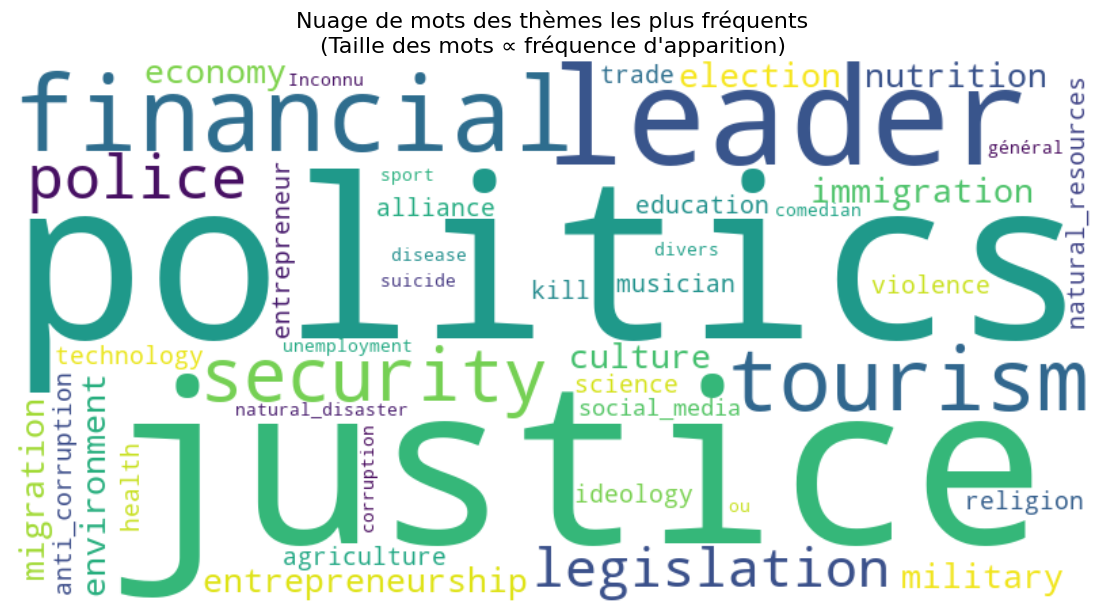

In [ ]:

# Pour réaliser un Nuage de mots des thèmes les plus abordés


import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud


# EXTRACTION DES THÈMES

# Suppression des valeurs nulles + séparation des thèmes
all_themes = df_Theme["Theme"].dropna().str.split(',').sum()

# Comptage des occurrences
theme_counts = Counter(all_themes)

# Récupération des thèmes fréquents (>= 5 occurrences)
frequent_themes = [theme for theme, count in theme_counts.items() if count >= 5]


# VISUALISATION : WORDCLOUD


if frequent_themes:
    text = " ".join(frequent_themes)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(14, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")

    # Titre + interprétation intégrée
    plt.title(
        "Nuage de mots des thèmes les plus fréquents\n"
        "(Taille des mots ∝ fréquence d'apparition)",
        fontsize=16
    )

    plt.show()

    
else:
    print("Aucun thème fréquent trouvé.")

## INTERPRÉTATION
    
- Les mots les plus grands représentent les thèmes dominants dans le corpus.  
- Cela permet d’identifier rapidement les sujets les plus traités dans les articles.  
- Une forte présence de certains thèmes peut indiquer une tendance médiatique ou politique.


## 3.1.3 Graphique linéaire pour montrer l'évolution des thémes les plus mentionnés en fonction du temps.


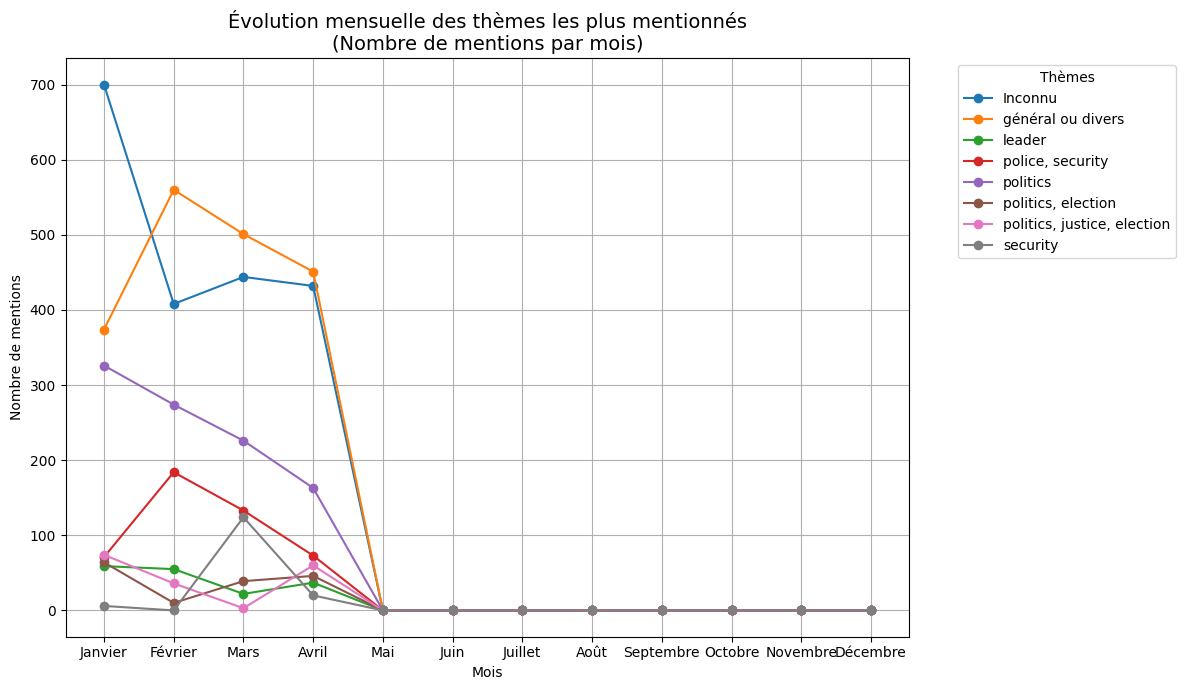

In [ ]:


# COPIE DE TRAVAIL

df_plot = df_Theme.copy()


# EXTRACTION DU MOIS (depuis SQLDATE au format YYYYMMDD)

# On force en chaîne pour éviter les problèmes si SQLDATE est numérique
df_plot["SQLDATE"] = df_plot["SQLDATE"].astype(str)

# Extraction des caractères 5 et 6 de SQLDATE (XXXXXXXX) pour récupérer le mois
df_plot["Month"] = df_plot["SQLDATE"].str[4:6]


# MAPPING MOIS → NOM

month_map = {
    "01": "Janvier", "02": "Février", "03": "Mars", "04": "Avril",
    "05": "Mai", "06": "Juin", "07": "Juillet", "08": "Août",
    "09": "Septembre", "10": "Octobre", "11": "Novembre", "12": "Décembre"
}

df_plot["Month"] = df_plot["Month"].map(month_map)

# Ordre chronologique des mois
month_order = ["Janvier","Février","Mars","Avril","Mai","Juin","Juillet","Août","Septembre","Octobre","Novembre","Décembre"]
df_plot["Month"] = pd.Categorical(df_plot["Month"], categories=month_order, ordered=True)


# COMPTAGE : nombre de mentions par (Mois, Thème)

# Si une cellule "Theme" contient plusieurs thèmes séparés (ex: "A;B;C"),
# on les éclate en lignes distinctes
df_plot["Theme"] = df_plot["Theme"].astype(str)
df_plot = df_plot.assign(Theme=df_plot["Theme"].str.split(";")).explode("Theme")

# Nettoyage (espaces)
df_plot["Theme"] = df_plot["Theme"].str.strip()

# Comptage
counts = (
    df_plot
    .groupby(["Month", "Theme"], observed=False)
    .size()
    .reset_index(name="Count")
)


# OPTION : filtrer les thèmes les plus fréquents (lisibilité)

top_n = 8  # pour spécifier le nombre de thèmes à sélectionner (ici, les 8 premiers).
top_themes = (
    counts.groupby("Theme")["Count"].sum()  # Regroupe les données par thème et calcule la somme des valeurs dans la colonne "Count" pour chaque groupe.
    .sort_values(ascending=False)   # Trie les thèmes par leur compte total, du plus élevé au plus bas. 
    .head(top_n)                   # Sélectionne les top_n (8) premiers thèmes après le tri.
    .index                        #Récupère les noms (étiquettes) de ces 8 thèmes les plus fréquents, qui sont ensuite stockés dans la variable top_themes
)

counts_top = counts[counts["Theme"].isin(top_themes)]


# PIVOT POUR MULTI-SÉRIES

pivot_df = counts_top.pivot(index="Month", columns="Theme", values="Count").fillna(0)

# Réindexation pour garantir tous les mois (même sans données)
pivot_df = pivot_df.reindex(month_order)


# VISUALISATION : LINE CHART MULTI-SÉRIES

plt.figure(figsize=(12, 7))

for theme in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[theme],
        marker='o',
        label=theme
    )

# Titres et axes
plt.title(
    "Évolution mensuelle des thèmes les plus mentionnés\n"
    "(Nombre de mentions par mois)",
    fontsize=14
)
plt.xlabel("Mois")
plt.ylabel("Nombre de mentions")

# Légende
plt.legend(title="Thèmes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()




### INTERPRÉTATION

- Chaque courbe représente l’évolution mensuelle d’un thème.
- Les pics indiquent des périodes de forte médiatisation d’un thème donné.
- La comparaison entre courbes met en évidence les thèmes dominants et leur évolution relative.
- Une stabilité suggère une présence continue dans l’actualité, tandis que des variations brusques indiquent des événements ponctuels.

## 3.2 Top Organisations

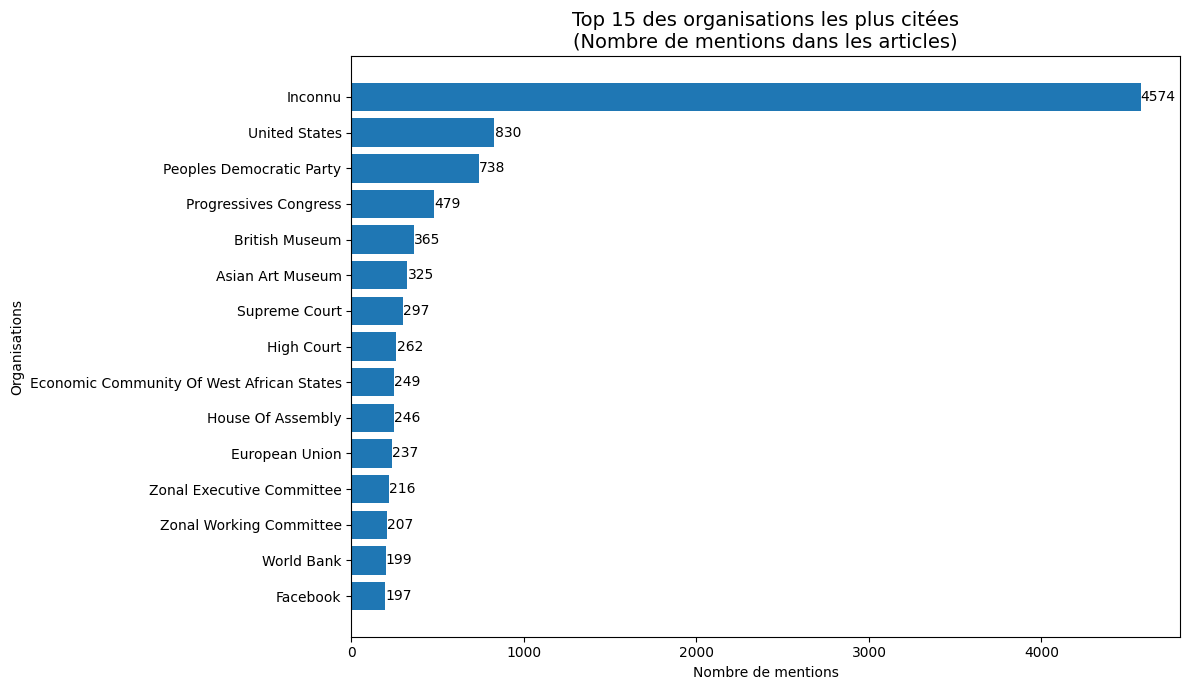

In [ ]:


# FONCTION D’EXTRACTION

def extract_organization_names(org_series):
    """
    Extrait uniquement les noms d'organisations
    depuis une chaîne de type :
    'ORG1,info;ORG2,info'
    """
    org_names = []

    for row in org_series.dropna():
        items = row.split(';')

        for item in items:
            parts = item.split(',')
            if parts:
                org_names.append(parts[0].strip())

    return org_names


# EXTRACTION + COMPTAGE

all_org = extract_organization_names(df_Joinn1["V2Organizations"])
org_counts = Counter(all_org)

# Top N organisations
top_n = 15
top_org = org_counts.most_common(top_n)


# PRÉPARATION DES DONNÉES

labels = [org for org, count in top_org]
values = [count for org, count in top_org]


# VISUALISATION : Diagramme en bâtons ( bar chart )

plt.figure(figsize=(12, 7))

bars = plt.barh(labels, values)  # bar chart horizontal (meilleur pour lisibilité)

# Inverser l’ordre pour avoir le plus grand en haut
plt.gca().invert_yaxis()

# Titres et labels
plt.title(
    f"Top {top_n} des organisations les plus citées\n"
    "(Nombre de mentions dans les articles)",
    fontsize=14
)

plt.xlabel("Nombre de mentions")
plt.ylabel("Organisations")


# AJOUT DES VALEURS SUR LES BARRES

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,                     # position horizontale
        bar.get_y() + bar.get_height()/2,
        str(width),                   # valeur affichée
        va='center'
    )

plt.tight_layout()
plt.show()




##  INTERPRÉTATION

    
- Ce graphique présente les organisations les plus mentionnées dans le corpus.
- Plus une barre est longue, plus l'organisation est médiatiquement visible.
- Les premières positions représentent les acteurs dominants dans les événements analysés.
- Une forte concentration sur quelques organisations peut indiquer une centralisation du pouvoir ou de l'attention médiatique.


## 3.3 Analyse et interprétation de la colonne EventCode

In [ ]:

# CE CODE PERMET DE DECODER TOUS LES CODES CAMEO QUI SE TROUVE DANS LA COLONNE EventCode du dataframe, pour une analyse approfondir



# ─────────────────────────────────────────────
# DICTIONNAIRE COMPLET DES CODES CAMEO
# Source : CAMEO Codebook v1.1b3 / GDELT
# ─────────────────────────────────────────────

cameo_codes = {
    # 01: FAIRE UNE DÉCLARATION PUBLIQUE
    "010": "Faire une déclaration publique (non spécifié ailleurs)",
    "011": "Refuser de commenter",
    "012": "Faire un commentaire pessimiste",
    "013": "Faire un commentaire optimiste",
    "014": "Envisager une option politique",
    "015": "Reconnaître ou revendiquer la responsabilité",
    "016": "Nier la responsabilité",
    "017": "S'engager dans un acte symbolique",
    "018": "Faire un commentaire empathique",
    "019": "Exprimer son accord",

    # 02: APPEL / REQUÊTE
    "020": "Faire un appel ou une demande (non spécifié ailleurs)",
    "021": "Appel à la coopération matérielle",
    "0211": "Appel à une coopération économique",
    "0212": "Appel à une coopération militaire",
    "0213": "Appel à une coopération judiciaire",
    "0214": "Appel à une coopération en matière de renseignement",
    "022": "Appel à la coopération diplomatique",
    "023": "Appel à l'aide",
    "0231": "Appel à une aide économique",
    "0232": "Appel à une aide militaire",
    "0233": "Appel à une aide humanitaire",
    "0234": "Appel à une protection militaire ou maintien de la paix",
    "024": "Appel à une réforme politique",
    "0241": "Appel à un changement de direction",
    "0242": "Appel à un changement de politique",
    "0243": "Appel à un changement de régime",
    "0244": "Appel à des droits démocratiques",
    "025": "Appel à céder / faire des concessions",
    "0251": "Appel à un assouplissement des sanctions administratives",
    "0252": "Appel à un assouplissement des restrictions populaires",
    "0253": "Appel à la libération de prisonniers",
    "0254": "Appel à l'arrêt du boycott ou de l'embargo",
    "0255": "Appel à l'arrêt du gel des avoirs",
    "0256": "Appel à l'arrêt des sanctions militaires",
    "026": "Appel aux autres à se rencontrer ou négocier",
    "027": "Appel aux autres à régler un différend",
    "028": "Appel à s'engager dans ou accepter une médiation",

    # 03: EXPRIMER L'INTENTION DE COOPÉRER
    "030": "Exprimer l'intention de coopérer (non spécifié)",
    "031": "Exprimer l'intention de s'engager dans une coopération matérielle",
    "0311": "Intention de coopération économique",
    "0312": "Intention de coopération militaire",
    "0313": "Intention de coopération judiciaire",
    "0314": "Intention de coopération en matière de renseignement",
    "032": "Exprimer l'intention de coopération diplomatique",
    "033": "Exprimer l'intention de fournir une aide matérielle",
    "0331": "Intention de fournir une aide économique",
    "0332": "Intention de fournir une aide militaire",
    "0333": "Intention de fournir une aide humanitaire",
    "0334": "Intention de fournir une protection militaire/maintien de la paix",
    "034": "Exprimer l'intention d'instaurer une réforme politique",
    "0341": "Intention de changer de direction",
    "0342": "Intention de changer de politique",
    "0343": "Intention de changer de régime",
    "0344": "Intention de donner des droits démocratiques",
    "035": "Exprimer l'intention de céder / faire des concessions",
    "0351": "Intention d'assouplir les sanctions administratives",
    "0352": "Intention d'assouplir les restrictions populaires",
    "0353": "Intention de libérer des prisonniers",
    "0354": "Intention d'arrêter le boycott ou l'embargo",
    "0355": "Intention d'arrêter le gel des avoirs",
    "0356": "Intention d'arrêter les sanctions militaires",
    "036": "Exprimer l'intention de se rencontrer ou de négocier",
    "037": "Exprimer l'intention de régler un différend",
    "038": "Exprimer l'intention d'accepter une médiation",
    "039": "Exprimer l'intention de servir de médiateur",

    # 04: CONSULTER
    "040": "Consulter (non spécifié)",
    "041": "Discuter par téléphone",
    "042": "Effectuer une visite officielle",
    "043": "Recevoir une visite officielle",
    "044": "Se rencontrer dans un lieu tiers",
    "045": "Assurer une médiation",
    "046": "S'engager dans une négociation formelle",

    # 05: ENGAGER UNE COOPÉRATION DIPLOMATIQUE
    "050": "Coopération diplomatique (non spécifiée)",
    "051": "Louer ou approuver",
    "052": "Défendre verbalement",
    "053": "Mobiliser du soutien en faveur de",
    "054": "Accorder une reconnaissance diplomatique",
    "055": "Habiliter ou autoriser",
    "056": "S'excuser",
    "057": "Pardonner",

    # 06: ENGAGER UNE COOPÉRATION MATÉRIELLE
    "060": "Engagement matériel (non spécifié)",
    "061": "Coopération économique",
    "062": "Coopération militaire",
    "063": "Coopération judiciaire",
    "064": "Coopération en matière de renseignement",

    # 07: FOURNIR DE L'AIDE
    "070": "Fournir de l'aide (non spécifiée)",
    "071": "Fournir une aide économique",
    "072": "Fournir une aide militaire",
    "073": "Fournir une aide humanitaire",
    "074": "Fournir une protection militaire ou maintien de la paix",
    "075": "Accorder l'asile",

    # 08: CÉDER / CONCÉDER
    "080": "Céder (non spécifié)",
    "081": "Assouplir les sanctions administratives",
    "0811": "Lever les restrictions de voyage",
    "0812": "Lever l'état d'urgence ou le couvre-feu",
    "0813": "Lever l'interdiction des organisations politiques",
    "0814": "Assouplir la censure",
    "082": "Assouplir les restrictions populaires (manifestations)",
    "083": "Libérer des prisonniers",
    "0831": "Libérer des prisonniers politiques",
    "0832": "Libérer des prisonniers de guerre",
    "0833": "Libérer des otages",
    "0834": "Gracier / Amnistier",
    "084": "Mettre fin à une sanction économique",
    "0841": "Arrêter le boycott ou l'embargo",
    "0842": "Arrêter le gel des avoirs",
    "085": "Mettre fin à une sanction militaire",
    "086": "Permettre une présence extérieure",
    "0861": "Recevoir des soldats de la paix",
    "0862": "Recevoir des inspecteurs",
    "0863": "Permettre le déploiement d'une aide humanitaire",
    "087": "Restituer / Retirer",
    "0871": "Restituer des biens",
    "0872": "Retirer des troupes",
    "0873": "Restituer des territoires occupés",
    "0874": "Rapatrier des réfugiés",

    # 09: ENQUÊTER
    "090": "Enquêter (non spécifié)",
    "091": "Enquêter sur un crime ou une corruption",
    "092": "Enquêter sur une violation des droits de l'homme",
    "093": "Enquêter sur une activité militaire/terroriste",
    "094": "Enquêter sur des données économiques",

    # 10: EXIGER / DEMANDER FERMEMENT
    "100": "Exiger (non spécifié)",
    "101": "Exiger une coopération matérielle",
    "1011": "Exiger une coopération économique",
    "1012": "Exiger une coopération militaire",
    "1013": "Exiger une coopération judiciaire",
    "1014": "Exiger une coopération en renseignement",
    "102": "Exiger une coopération diplomatique",
    "103": "Exiger de l'aide",
    "1031": "Exiger une aide économique",
    "1032": "Exiger une aide militaire",
    "1033": "Exiger une aide humanitaire",
    "1034": "Exiger une protection militaire",
    "104": "Exiger une réforme politique",
    "1041": "Exiger un changement de direction",
    "1042": "Exiger un changement de politique",
    "1043": "Exiger un changement de régime",
    "1044": "Exiger des droits démocratiques",
    "105": "Exiger de céder / concessions",
    "1051": "Exiger l'assouplissement de sanctions administratives",
    "1052": "Exiger l'assouplissement de restrictions populaires",
    "1053": "Exiger la libération de prisonniers",
    "1054": "Exiger l'arrêt du boycott ou de l'embargo",
    "1055": "Exiger l'arrêt du gel des avoirs",
    "1056": "Exiger l'arrêt des sanctions militaires",
    "106": "Exiger une rencontre ou négociation",
    "107": "Exiger le règlement d'un différend",
    "108": "Exiger une médiation",

    # 11: DÉSAPPROUVER
    "110": "Désapprouver (non spécifié)",
    "111": "Critiquer ou condamner",
    "112": "Porter des accusations",
    "1121": "Accusation de crime/corruption",
    "1122": "Accusation de violation des droits de l'homme",
    "1123": "Accusation d'activité terroriste",
    "1124": "Accusation d'activité militaire illégale",
    "1125": "Accusation d'espionnage",
    "113": "Se plaindre officiellement",
    "114": "Réprimander ou blâmer",
    "115": "Avertir",
    "116": "Émettre une protestation diplomatique",

    # 12: REJETER
    "120": "Rejeter (non spécifié)",
    "121": "Rejeter une coopération matérielle",
    "1211": "Rejeter une coopération économique",
    "1212": "Rejeter une coopération militaire",
    "1213": "Rejeter une coopération judiciaire",
    "1214": "Rejeter une coopération en renseignement",
    "122": "Rejeter une coopération diplomatique",
    "1221": "Rejeter une demande de reconnaissance",
    "1222": "Rejeter une proposition de paix",
    "1223": "Rejeter un accord",
    "1224": "Rejeter une médiation",
    "123": "Rejeter une aide",
    "1231": "Rejeter une aide économique",
    "1232": "Rejeter une aide militaire",
    "1233": "Rejeter une aide humanitaire",
    "1234": "Rejeter une protection militaire",
    "124": "Rejeter une réforme politique",
    "1241": "Rejeter un changement de direction",
    "1242": "Rejeter un changement de politique",
    "1243": "Rejeter un changement de régime",
    "1244": "Rejeter des droits démocratiques",
    "1245": "Rejeter une demande d'élections",
    "1246": "Rejeter une demande de constitution",
    "125": "Rejeter une demande de concession",
    "126": "Rejeter une demande de rencontre",
    "127": "Rejeter une demande de règlement de différend",
    "128": "Rejeter une demande de médiation",
    "129": "Rejeter une demande d'asile",

    # 13: MENACER
    "130": "Menacer (non spécifié)",
    "131": "Menace de réduire la coopération matérielle",
    "1311": "Menace de réduction économique",
    "1312": "Menace de réduction militaire",
    "1313": "Menace de réduction judiciaire",
    "132": "Menace de réduire la coopération diplomatique",
    "1321": "Menace de rompre les relations diplomatiques",
    "1322": "Menace de retrait de reconnaissance",
    "1323": "Menace d'annulation d'accord",
    "1324": "Menace de boycott diplomatique",
    "133": "Menacer de réduire l'aide",
    "134": "Menacer de sanctions administratives",
    "135": "Menacer de sanctions populaires (restrictions)",
    "136": "Menacer d'embargo ou de gel des avoirs",
    "137": "Menacer de sanctions militaires",
    "138": "Menacer d'utiliser la force",
    "1381": "Menace de blocus",
    "1382": "Menace d'occupation",
    "1383": "Menace de bombardement",
    "1384": "Menace d'attaque nucléaire",
    "1385": "Menace d'attaque biologique/chimique",
    "139": "Menacer d'un procès/poursuites",

    # 14: PROTESTER
    "140": "Protester (non spécifié)",
    "141": "Manifester ou protester (civil)",
    "1411": "Grève ou arrêt de travail",
    "1412": "Manifestation de rue",
    "1413": "Occupation de bâtiments",
    "1414": "Grève de la faim",
    "142": "Conduite de boycott armé",
    "1421": "Boycott économique",
    "1422": "Boycott diplomatique",
    "1423": "Boycott culturel/sportif",
    "1424": "Boycott des élections",
    "143": "Entraver la liberté de mouvement",
    "1431": "Fermer les frontières",
    "1432": "Imposer un couvre-feu",
    "1433": "Imposer l'état d'urgence",
    "1434": "Bloquer les communications",
    "144": "Censure ou restriction d'information",
    "1441": "Fermer des médias",
    "1442": "Expulser des journalistes",
    "1443": "Interrompre l'accès Internet",
    "1444": "Confisquer des publications",
    "145": "Action administrative coercitive",
    "1451": "Expulser des individus (non diplomates)",
    "1452": "Retirer des passeports",
    "1453": "Geler des comptes bancaires",
    "1454": "Révoquer des licences",

    # 15: EXHIBER UNE POSTURE MILITAIRE
    "150": "Posturer militairement (non spécifié)",
    "151": "Augmenter l'alerte militaire",
    "152": "Faire une démonstration de force",
    "153": "Mobiliser des troupes de réserve",
    "154": "Mobiliser ou augmenter les forces armées",
    "155": "Mener des exercices militaires",

    # 16: RÉDUIRE LES RELATIONS
    "160": "Réduire les relations (non spécifié)",
    "161": "Réduire ou rompre les relations diplomatiques",
    "162": "Réduire ou rompre l'aide matérielle",
    "1621": "Réduire l'aide économique",
    "1622": "Réduire l'aide militaire",
    "1623": "Réduire l'aide humanitaire",
    "163": "Suspendre ou rompre un accord",
    "164": "Interrompre les négociations",
    "165": "Rappeler un ambassadeur",
    "166": "Expulser du personnel diplomatique",
    "1661": "Expulser un ambassadeur",
    "1662": "Expulser des attachés",
    "1663": "Réduire la taille de la mission",

    # 17: COERCITION
    "170": "Coercition (non spécifiée)",
    "171": "Saisie administrative de biens",
    "1711": "Confisquer des biens privés",
    "1712": "Nationaliser des biens étrangers",
    "172": "Imposer des restrictions physiques",
    "1721": "Arrêt ou détention",
    "1722": "Imposer une assignation à résidence",
    "1723": "Emprisonnement",
    "1724": "Exil ou bannissement",
    "173": "Torturer",
    "174": "Exécuter",
    "175": "Utiliser des tactiques de police (gaz, canons à eau)",
    "176": "Démolir des propriétés",

    # 18: ASSAUT
    "180": "Assaut (non spécifié)",
    "181": "Invasion",
    "182": "Attaque armée",
    "1821": "Fusillade",
    "1822": "Attaque à l'arme blanche",
    "1823": "Attentat à la voiture piégée",
    "183": "Utilisation d'engins explosifs",
    "1831": "Bombardement terrestre",
    "1832": "Attentat suicide",
    "1833": "Grenade ou mortier",
    "1834": "Mines terrestres",
    "184": "Assaut aérien",
    "185": "Assaut naval",
    "186": "Kidnapping ou prise d'otage",

    # 19: COMBAT
    "190": "Combattre (non spécifié)",
    "191": "Engagement de troupes au sol",
    "192": "Combats d'artillerie",
    "193": "Escarmouches frontalières",
    "194": "Combat naval",
    "195": "Combat aérien ou bombardement",
    "1951": "Frappes de missiles",
    "1952": "Utilisation de drones (munitions aériennes pilotées à distance)",
    "196": "Violer un cessez-le-feu",

    # 20: VIOLENCE DE MASSE NON CONVENTIONNELLE
    "200": "Violence de masse non conventionnelle (non spécifiée)",
    "201": "Expulsions massives de populations",
    "202": "Utilisation d'armes chimiques/biologiques",
    "203": "Utilisation d'armes nucléaires",
    "204": "Nettoyage ethnique ou Génocide",
    "2041": "Massacre délibéré de civils",
    "2042": "Destruction systématique de communautés",
}

# ─────────────────────────────────────────────
# FONCTION DE DECODAGE
# ─────────────────────────────────────────────

def decoder_eventcode(code):
    """
    Convertit un code CAMEO en sa signification textuelle.
    Le code est nettoyé et normalisé avant la recherche.
    Retourne 'Code inconnu' si le code n'est pas dans le dictionnaire.
    """
    if pd.isna(code):
        return "Valeur manquante"

    # Convertir en chaîne et supprimer les espaces
    code = str(code).strip()

    # Certains codes dans GDELT ont un zéro initial manquant
    # ex: "10" au lieu de "010" → on normalise à 3 caractères
    if len(code) == 2:
        code = "0" + code

    return cameo_codes.get(code, f"Code inconnu ({code})")




df_action = df_Joinn1[["EventCode"]].copy()
df_action["Action_menée"] = df_action["EventCode"].apply(decoder_eventcode)
df_action.head()


,EventCode,Action_menée
0,16,Nier la responsabilité
1,140,Protester (non spécifié)
2,43,Recevoir une visite officielle
3,42,Effectuer une visite officielle
4,20,Faire un appel ou une demande (non spécifié ai...


In [ ]:
df_action["Action_menée"].isna().sum()

0

## 3-3 Analyse et interprétation de la colonne QuadClass



In [ ]:

#  CE CODE PERMET DE DECODER LA COLONNE QuadClass du dataframe, pour mieux connaître les classes d'évènements 

mapping = {
    1: "Coopération verbale",
    2: "Coopération matérielle",
    3: "Conflit verbal",
    4: "Conflit matériel"
}

df_type = df_Joinn1[["QuadClass"]].copy()
df_type["Type_Evènement"] = df_type["QuadClass"].map(mapping)
df_type.head()



,QuadClass,Type_Evènement
0,1,Coopération verbale
1,3,Conflit verbal
2,1,Coopération verbale
3,1,Coopération verbale
4,1,Coopération verbale


In [ ]:
df_type["Type_Evènement"].isna().sum()

0

## 3.4 Classification des évènements 


In [ ]:

df_analyse1 = pd.DataFrame({
    "EventCode": df_action["EventCode"].values,        #  .values garantit que les données sont récupérées ligne par ligne sans alignement d’index
    "Action_menée": df_action["Action_menée"].values,
    "Type_Evènement": df_type["Type_Evènement"].values
})

df_analyse1.head()

,EventCode,Action_menée,Type_Evènement
0,16,Nier la responsabilité,Coopération verbale
1,140,Protester (non spécifié),Conflit verbal
2,43,Recevoir une visite officielle,Coopération verbale
3,42,Effectuer une visite officielle,Coopération verbale
4,20,Faire un appel ou une demande (non spécifié ai...,Coopération verbale


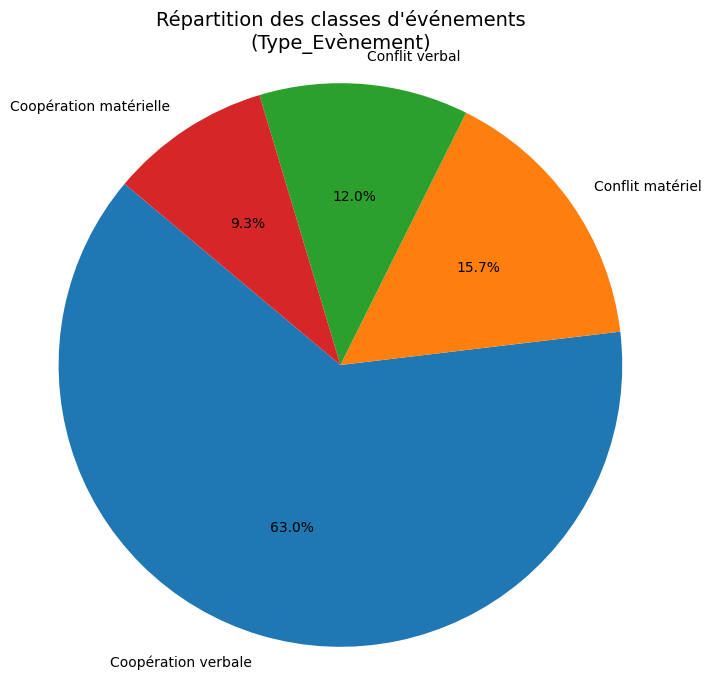

In [ ]:

# Diagramme circulaire pour la classification des évènements


# COMPTAGE DES CLASSES

type_counts = df_analyse1["Type_Evènement"].value_counts()


# VISUALISATION

plt.figure(figsize=(8, 8))

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(
    "Répartition des classes d'événements\n"
    "(Type_Evènement)",
    fontsize=14
)

plt.axis('equal')  # Cercle parfait
plt.show()




##  INTERPRÉTATION
   
- Ce graphique montre la distribution globale des types d’événements.
- Une classe dominante indique une tendance générale (ex : conflits vs coopération.


## 3.5 Analyse et interprétation de la colonne GoldsteinScale

In [ ]:

# Pour interpreter L'échelle de Goldstein au niveau de la colonne GoldsteinScale

def classify_impact(x):
    if pd.isna(x):
        return "Inconnu"
    elif -10.0 <= x <= -5.0:
        return "Action conflictuelle très négative"
    elif -5.0 < x < 0.0:
        return "Action conflictuelle négative"
    elif x == 0.0:
        return "Action neutre"
    elif 0.0 < x <= 5.0:
        return "Action coopérative positive"
    elif 5.0 < x <= 10.0:
        return "Action coopérative très positive"
    else:
        return "Inconnu"


df_Impact = df_Joinn1[["GoldsteinScale"]].copy()
df_Impact["Impact_Evènement"] = df_Impact["GoldsteinScale"].apply(classify_impact)
df_Impact.head()


,GoldsteinScale,Impact_Evènement
0,-2.0,Action conflictuelle négative
1,-6.5,Action conflictuelle très négative
2,2.8,Action coopérative positive
3,1.9,Action coopérative positive
4,3.0,Action coopérative positive


In [ ]:
df_Impact["Impact_Evènement"].isna().sum()

0

In [ ]:

df_analyse2 = pd.DataFrame({
    "Type_Evènement": df_type["Type_Evènement"].values,
    "GoldsteinScale": df_Impact["GoldsteinScale"].values,
    "Impact_Evènement": df_Impact["Impact_Evènement"].values
})

df_analyse2.head()

,Type_Evènement,GoldsteinScale,Impact_Evènement
0,Coopération verbale,-2.0,Action conflictuelle négative
1,Conflit verbal,-6.5,Action conflictuelle très négative
2,Coopération verbale,2.8,Action coopérative positive
3,Coopération verbale,1.9,Action coopérative positive
4,Coopération verbale,3.0,Action coopérative positive


## 3.6 Analyse des types d'évènements et leurs impactes 

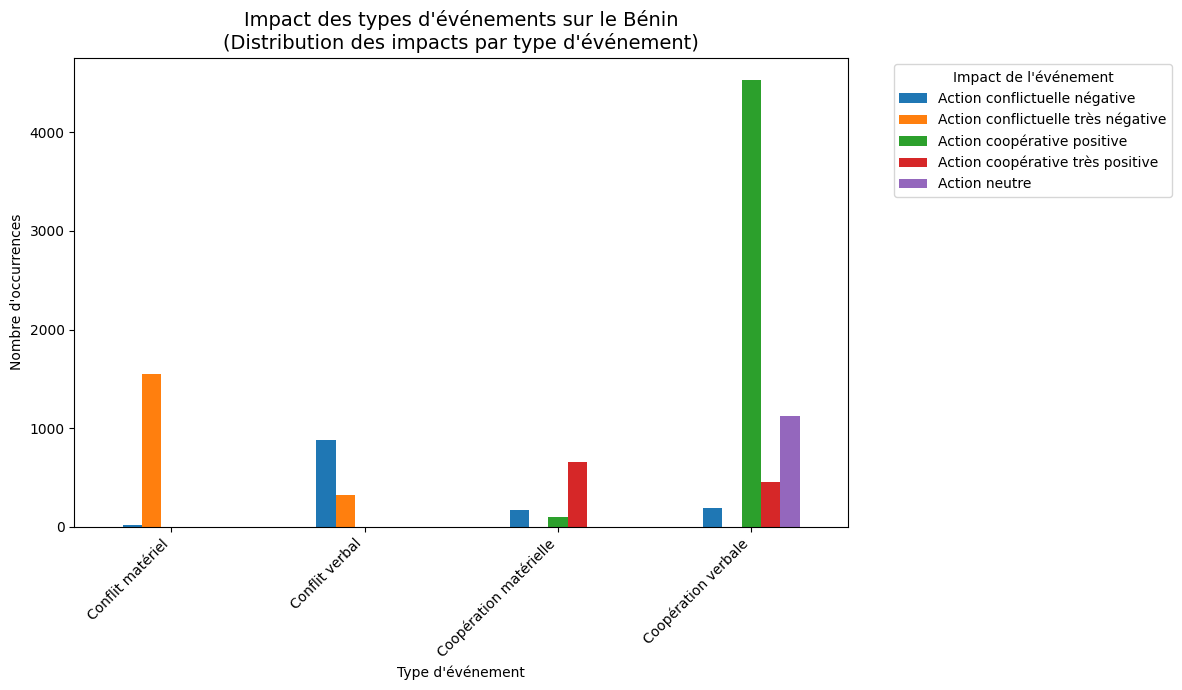

In [ ]:


# TABLE DE CONTINGENCE

# On croise Type_Evènement et Impact_Evènement
cross_tab = pd.crosstab(
    df_analyse2["Type_Evènement"],
    df_analyse2["Impact_Evènement"]
)


# VISUALISATION

cross_tab.plot(
    kind="bar",
    figsize=(12, 7)
)


# HABILLAGE DU GRAPHIQUE

plt.title(
    "Impact des types d'événements sur le Bénin\n"
    "(Distribution des impacts par type d'événement)",
    fontsize=14
)

plt.xlabel("Type d'événement")
plt.ylabel("Nombre d'occurrences")

# Rotation pour lisibilité
plt.xticks(rotation=45, ha="right")

# Légende = types d’impact
plt.legend(
    title="Impact de l'événement",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()




##  INTERPRÉTATION


- Chaque groupe de barres correspond à un type d’événement (ex : coopération, conflit).
- Les couleurs représentent les différents niveaux d’impact (positif, négatif, neutre).
- La hauteur des barres indique la fréquence des événements pour chaque combinaison.")
- Permet d’identifier quels types d’événements ont les impacts les plus négatifs ou positifs.
- Par exemple :
  - Si les conflits matériels sont majoritairement associés à des impacts très négatifs, cela confirme leur gravité.
  - Si la coopération est associée à des impacts positifs, cela montre son rôle stabilisateur.

## 3.7 ANALYSE DES SENTIMENTS

In [ ]:


# .copy() évite de modifier le DataFrame original df par erreur
df_tone = df_Joinn1[["V2Tone"]].copy()


# EXTRACTION DE LA PREMIÈRE VALEUR

df_tone["Tone_1"] = pd.to_numeric(
    df_tone["V2Tone"].str.split(",").str[0],  # On découpe la chaîne sur "," et on prend la 1ère valeur
    errors="coerce"                           # Si une valeur est invalide, elle devient NaN au lieu de planter
)


# CLASSIFICATION DU SENTIMENT

df_tone["Sentiment"] = np.where(
    df_tone["Tone_1"] < 0,                    # Condition 1 : si la valeur est négative
    "Mécontent",                              # Valeur associée si condition vraie
    np.where(
        df_tone["Tone_1"] == 0,               # Condition 2 : si la valeur est exactement 0
        "Indifférent",                         # Valeur associée si condition vraie
        "Content"                              # Sinon (donc > 0)
    )
)


#df_tone.drop(columns=["Tone_1"], inplace=True)
# On supprime la colonne intermédiaire "Tone_1" si on ne veut garder que le résultat final


df_tone.head()


,V2Tone,Tone_1,Sentiment
0,"-11.6822429906542,1.86915887850467,13.55140186...",-11.682243,Mécontent
1,"-5.14018691588785,2.33644859813084,7.476635514...",-5.140187,Mécontent
2,"-5.14018691588785,2.33644859813084,7.476635514...",-5.140187,Mécontent
3,"-5.14018691588785,2.33644859813084,7.476635514...",-5.140187,Mécontent
4,"-11.6822429906542,1.86915887850467,13.55140186...",-11.682243,Mécontent


In [ ]:

df_Joinn1 = pd.read_csv("GDELT_DATA_BENIN_2025.csv")
df_Joinn1.head()

,SQLDATE,MentionTimeDate,GlobalEventID,Actor1Name,Actor2Name,EventCode,QuadClass,GoldsteinScale,AvgTone,ActionGeo_Fullname,MentionDocTone,Confidence,V2Organizations,V2Tone,MentionSourceName,SOURCEURL
0,20250101,20250101003000,1218370422,GOVERNOR,BENIN,16,1,-2.0,-12.206573,Benin,-12.206573,20,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...
1,20250101,20250101003000,1218370056,BENIN,NIGER,140,3,-6.5,-5.581395,Benin,-5.581395,100,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
2,20250101,20250101003000,1218370660,NIGERIEN,BENIN,43,1,2.8,-5.581395,Benin,-5.581395,20,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
3,20250101,20250101003000,1218370058,BENINESE,NIGERIEN,42,1,1.9,-5.581395,Benin,-5.581395,80,Inconnu,"-5.14018691588785,2.33644859813084,7.476635514...",guardian.ng,https://guardian.ng/news/benin-protests-remark...
4,20250101,20250101003000,1218370051,BENIN,Inconnu,20,1,3.0,-12.206573,Benin,-12.206573,100,"House Of Assembly,528;House Of Assembly,1542;P...","-11.6822429906542,1.86915887850467,13.55140186...",punchng.com,https://punchng.com/pdp-seeks-igs-intervention...


# 3.8. Imports


In [ ]:
import requests
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from dash import Dash, dcc, html, Input, Output
from sklearn.linear_model import LogisticRegression

### 3.9 Chargement des données


In [ ]:

# Veuillez remplacer le contenu de la variables "PATH" pointant vers les données dans votre cas.
PATH = "C:/Users/adama/3D Objects/obsidiant/iSheero/Hackathon/gdelt-benin/data/processed/GDELT_DATA_BENIN_2025-1.csv"

df = pd.read_csv(PATH)

df.head()

# 4. Prétraitement

### 4.1. Suppression des valeur maquante

In [ ]:
df["date"] = pd.to_datetime(df["SQLDATE"], format="%Y%m%d", errors="coerce") # Formatage de des dates.
df["tone"] = pd.to_numeric(df["AvgTone"], errors="coerce") # Numérisation des valeurs moyennes des tons.
df["impact"] = pd.to_numeric(df["GoldsteinScale"], errors="coerce") # Numérisation de l'échelle de Goldstein.

df = df.dropna(subset=["date"])

### 4.2. liste des codes valides

In [ ]:
VALID_CODES = {f"{i:02d}" for i in range(1, 21)}

### 4.3. Nettoyage

In [ ]:
df["EventRootCode"] = (
    df["EventCode"]
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(3)
    .str[:2]
)

df = df[df["EventRootCode"].isin(VALID_CODES)]

df["EventRootCode"] = df["EventRootCode"].where(
    df["EventRootCode"].isin(VALID_CODES),
    "00"
)

### 4.4. Mapping

In [ ]:
df["EventCategory"] = (
    df["EventRootCode"]
    .map(cameo_codes)
    .fillna("Inconnu")
)

# 4. Analyse exploratoire

## 4.1 Timeline des événements

In [ ]:
timeline = (
    df.groupby(df["date"].dt.date)
    .size()
    .reset_index(name="count")
    .sort_values("date")
)

fig = px.line(
    timeline,
    x="date",
    y="count",
    title="Évolution des événements au Bénin"
)

fig.show()

### Ce que ça signifie :

- évolution du nombre d’événements dans le temps
- donc : activité géopolitique au Bénin

## 4.4 Quel acteur fait quel type d’événement ?

In [ ]:
cross = (
    df.groupby(["Actor1Name", "EventCategory"])
    .size()
    .reset_index(name="count")
)

top_actors = df["Actor1Name"].value_counts().head(5).index

cross = cross[cross["Actor1Name"].isin(top_actors)]

fig = px.bar(
    cross,
    x="Actor1Name",
    y="count",
    color="EventCategory",
    title="Types d'événements par acteur"
)

fig.show()

### Ce que ça apporte

Tu peux dire :

- "La police est surtout liée aux protestations"
- "Le gouvernement est lié aux déclarations publiques"
- "Certains acteurs sont liés à la violence"

## 4.5 Distribution du ton


In [ ]:
fig = px.histogram(
    df,
    x="tone",
    nbins=50,
    title="Distribution du ton (sentiment)",
)

fig.show()

### Interprétation

| valeur | signification                  |
| ------ | ------------------------------ |
| > 0    | positif (stable / coopération) |
| < 0    | négatif (conflits)             |
| 0      | neutre                         |

Ce n’est pas un graphique direct, c’est une statistique globale

# 5. Machine Learning

## 5.1 Création cible

### 5.2.1. Est-ce que GoldsteinScale permet de prédire un ton positif ou négatif ?

Pour comprendre ce que sait l'échelle de Goldstein (GoldsteinScale), rendez-vous au lien : [clic-moi](http://data.gdeltproject.org/documentation/CAMEO.Manual.1.1b3.pdf)

In [ ]:
X = df[["GoldsteinScale", "EventCode"]]
y = df["AvgTone"] > 0
model = LogisticRegression()
model.fit(X, y)

## 5.3 Prédiction

In [ ]:
df["prediction"] = model.predict(X)

df[["impact", "tone", "target", "prediction"]].head()

## 5.4 Visualisation ML

In [ ]:
fig = px.scatter(
    df,
    x="impact",
    y="tone",
    color="target",
    title="Relation Impact vs Sentiment",
)

fig.show()

In [ ]:
df["label"] = df["AvgTone"].apply(lambda x: "positive" if x > 0 else "negative")

fig = px.scatter(
    df,
    x="GoldsteinScale",
    y="AvgTone",
    color="label",
    color_discrete_map={
        "positive": "green",
        "negative": "red"
    },
    title="Relation Goldstein vs Tone (GDELT Bénin)"
)

fig.show()


### 5.5. Insight important
- Cluster rouge = zones de tension
- Cluster vert = stabilité / coopération
- L’axe X = impact géopolitique (GoldsteinScale)
- L’axe Y = tonalité médiatique (AvgTone)

# 6. Insights

### Insights clés

- Les événements sont concentrés sur certaines périodes → pics d'activité
- Certains acteurs dominent fortement les interactions
- Le sentiment global est (positif / négatif selon tes données)
- L’impact (GoldsteinScale) influence partiellement le ton

### ML

- Modèle simple mais fonctionnel
- Permet de prédire le ton à partir de l’impact
- Peut être amélioré avec plus de variables

# 7. Conclusion

### Conclusion

Ce projet démontre :

- Un pipeline complet de données (ingestion → analyse)
- Une API exploitable
- Des visualisations claires
- Une première approche Machine Learning

Ce système peut être étendu pour :
- monitoring en temps réel
- détection de crises
- analyse géopolitique avancée